# Project 1: Automatic Review Analyzer

This notebook compares Perceptron, Average Perceptron, and Pegasos on the complete 3,000-sentence UCI Sentiment Labelled Sentences dataset.

The workflow is: **reviews → train/validation/test → sparse `X` + labels `y` → three classifiers → lambda selection → final test comparison → learned weights → two-feature visualizations.**


In [1]:
from pathlib import Path
import random, re, sys, time, urllib.request, zipfile
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != 'project_1':
    candidate = PROJECT_DIR / 'unit_1' / 'project_1'
    if candidate.exists(): PROJECT_DIR = candidate
if str(PROJECT_DIR) not in sys.path: sys.path.insert(0, str(PROJECT_DIR))
from linear_classification import accuracy, average_perceptron, pegasos, perceptron


## 1. Dataset and reproducible split

The dataset contains 1,000 IMDb, 1,000 Amazon, and 1,000 Yelp sentences, balanced between positive and negative labels. The test set is untouched until the final evaluation.


In [2]:
DATA_URL = 'https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip'
DATA_DIR = PROJECT_DIR / 'data' / 'sentiment_labelled_sentences'
DATA_DIR.mkdir(parents=True, exist_ok=True)
ZIP_PATH = DATA_DIR / 'sentiment_labelled_sentences.zip'
if not ZIP_PATH.exists(): urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
with zipfile.ZipFile(ZIP_PATH) as archive: archive.extractall(DATA_DIR)
root = next(DATA_DIR.glob('**/sentiment labelled sentences'), DATA_DIR)
files = {'IMDb': root/'imdb_labelled.txt', 'Amazon': root/'amazon_cells_labelled.txt', 'Yelp': root/'yelp_labelled.txt'}

def read_source(path, source):
    rows=[]
    with path.open(encoding='utf-8') as f:
        for line in f:
            text, label = line.rstrip('\n').rsplit('\t', 1)
            rows.append((1 if label == '1' else -1, text, source))
    return rows
reviews=[r for source,path in files.items() for r in read_source(path, source)]
print('Total:', len(reviews), '| Positive:', sum(r[0]==1 for r in reviews), '| Negative:', sum(r[0]==-1 for r in reviews))
print({s:sum(r[2]==s for r in reviews) for s in files})

rng=random.Random(42)
def stratified_split(rows):
    groups={1:[], -1:[]}
    for row in rows: groups[row[0]].append(row)
    train=[]; validation=[]; test=[]
    for group in groups.values():
        group=group.copy(); rng.shuffle(group); n=len(group)
        a=int(.70*n); b=a+int(.15*n)
        train+=group[:a]; validation+=group[a:b]; test+=group[b:]
    rng.shuffle(train); rng.shuffle(validation); rng.shuffle(test)
    return train, validation, test
train_reviews, validation_reviews, test_reviews = stratified_split(reviews)
print(f'Train: {len(train_reviews)} | Validation: {len(validation_reviews)} | Test: {len(test_reviews)}')


Total: 3000 | Positive: 1500 | Negative: 1500
{'IMDb': 1000, 'Amazon': 1000, 'Yelp': 1000}
Train: 2100 | Validation: 450 | Test: 450


## 2. Build `X` and `y` separately

For vocabulary $V=\{w_1,\ldots,w_d\}$, each review becomes $x_i\in\mathbb{R}^d$ and labels form a separate vector $y\in\{-1,+1\}^m$. The vocabulary is learned from training data only.


In [3]:
TOKEN_RE=re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
def tokenize(text): return TOKEN_RE.findall(text.lower())
def build_vocabulary(rows, min_count=2):
    counts={}
    for _,text,_ in rows:
        for token in set(tokenize(text)): counts[token]=counts.get(token,0)+1
    return {w:i for i,w in enumerate(sorted(w for w,c in counts.items() if c>=min_count))}
def vectorize(rows, vocabulary):
    X=[]; y=[]
    for label,text,_ in rows:
        features={}
        for token in set(tokenize(text)):
            i=vocabulary.get(token)
            if i is not None: features[i]=1.0
        X.append(features); y.append(label)
    return X,np.asarray(y,dtype=int)
vocabulary=build_vocabulary(train_reviews)
X_train,y_train=vectorize(train_reviews,vocabulary)
X_validation,y_validation=vectorize(validation_reviews,vocabulary)
X_test,y_test=vectorize(test_reviews,vocabulary)
train_data=list(zip(y_train,X_train)); validation_data=list(zip(y_validation,X_validation)); test_data=list(zip(y_test,X_test))
print('Vocabulary:',len(vocabulary),'| X_train:',len(X_train),'| y_train:',len(y_train))


Vocabulary: 1766 | X_train: 2100 | y_train: 2100


## 3. Controlled comparison

All three classifiers receive the same training representation and the same number of epochs. Training time is measured rather than assumed.


In [4]:
EPOCHS=10; BATCH_SIZE=32; SEED=42
def timed(fn):
    start=time.perf_counter(); weights=fn(); return weights,time.perf_counter()-start
specs={
 'Perceptron':lambda:perceptron(train_data,epochs=EPOCHS),
 'Average Perceptron':lambda:average_perceptron(train_data,epochs=EPOCHS),
 'Pegasos (lambda=1e-3)':lambda:pegasos(train_data,lambda_=1e-3,epochs=EPOCHS,batch_size=BATCH_SIZE,seed=SEED)}
baseline_models={}; baseline_results=[]
for name,fn in specs.items():
    weights,elapsed=timed(fn); baseline_models[name]=weights; score=accuracy(weights,validation_data)
    baseline_results.append((name,elapsed,score)); print(f'{name:25} | {elapsed:.4f}s | validation={score:.2%}')


Perceptron                | 0.1322s | validation=75.11%
Average Perceptron        | 0.2007s | validation=78.89%
Pegasos (lambda=1e-3)     | 0.4651s | validation=79.56%


## 4. Select Pegasos `lambda`

We choose the smallest value achieving maximum validation accuracy:

$$\lambda^*=\arg\max_{\lambda}\mathrm{ValidationAccuracy}(\lambda).$$


lambda= 1.0e-06 | validation=56.89% | time=0.5529s
lambda= 1.0e-05 | validation=75.78% | time=0.5498s
lambda= 1.0e-04 | validation=74.44% | time=0.4465s
lambda= 5.0e-04 | validation=78.89% | time=0.4034s
lambda= 1.0e-03 | validation=79.56% | time=0.4956s
lambda= 5.0e-03 | validation=82.89% | time=0.4512s
lambda= 1.0e-02 | validation=82.44% | time=0.4860s
lambda= 5.0e-02 | validation=75.11% | time=0.4754s
lambda= 1.0e-01 | validation=71.56% | time=0.5683s
lambda= 5.0e-01 | validation=70.22% | time=0.5524s

Selected lambda*: 5.0e-03 | validation accuracy=82.89%


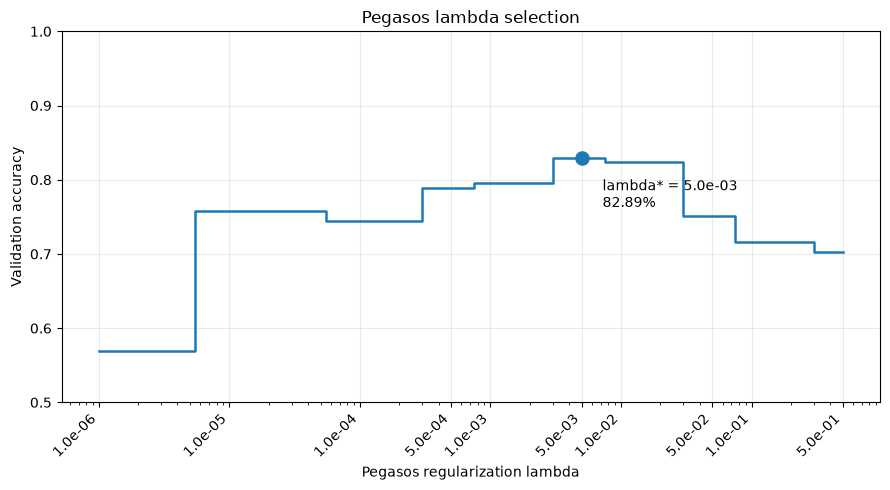

In [5]:
lambda_grid=np.array([1e-6,1e-5,1e-4,5e-4,1e-3,5e-3,1e-2,5e-2,1e-1,5e-1])
lambda_scores=[]; lambda_times=[]
for lam in lambda_grid:
    weights,elapsed=timed(lambda lam=lam:pegasos(train_data,lambda_=lam,epochs=EPOCHS,batch_size=BATCH_SIZE,seed=SEED))
    score=accuracy(weights,validation_data); lambda_scores.append(score); lambda_times.append(elapsed)
    print(f'lambda={lam:8.1e} | validation={score:.2%} | time={elapsed:.4f}s')
lambda_scores=np.asarray(lambda_scores)
best_score=float(lambda_scores.max()); best_lambda=float(lambda_grid[np.flatnonzero(lambda_scores==best_score)[0]])
print(f'\nSelected lambda*: {best_lambda:.1e} | validation accuracy={best_score:.2%}')

fig,ax=plt.subplots(figsize=(9,5))
ax.step(lambda_grid,lambda_scores,where='mid',linewidth=1.8)
ax.scatter([best_lambda],[best_score],s=90,zorder=3)
ax.set_xscale('log'); ax.set_xlabel('Pegasos regularization lambda'); ax.set_ylabel('Validation accuracy')
ax.set_title('Pegasos lambda selection'); ax.set_xticks(lambda_grid); ax.set_xticklabels([f'{x:.1e}' for x in lambda_grid],rotation=45,ha='right')
ax.set_ylim(0.5,1.0); ax.grid(True,alpha=.25)
ax.annotate(f'lambda* = {best_lambda:.1e}\n{best_score:.2%}',xy=(best_lambda,best_score),xytext=(15,-35),textcoords='offset points')
plt.tight_layout(); plt.show()


## 5. Final comparison on the untouched test set

Pegasos is retrained using the selected `lambda*`. Only now do we evaluate the final models on the test set.


Classifier           |  time(s) | validation |     test
--------------------------------------------------------
Perceptron           |   0.1385 |     75.11% |   72.00%
Average Perceptron   |   0.1867 |     78.89% |   78.00%
Pegasos              |   0.5003 |     82.89% |   79.33%


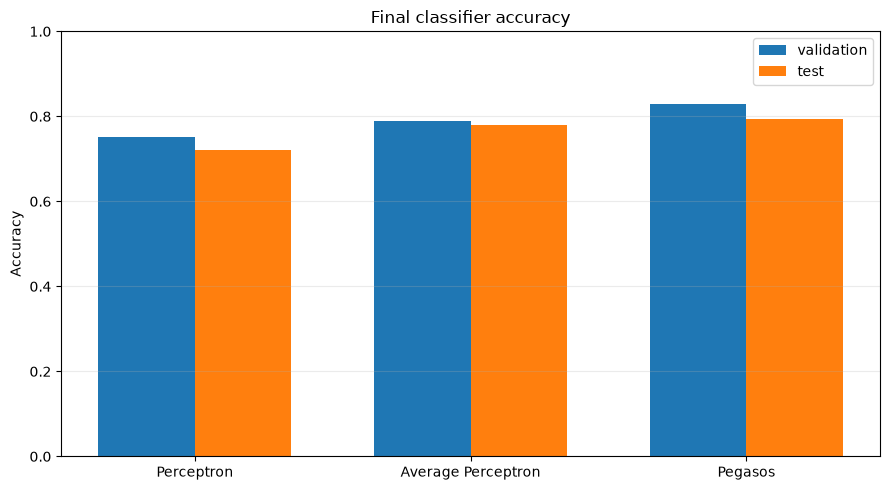

In [6]:
final_specs={
 'Perceptron':lambda:perceptron(train_data,epochs=EPOCHS),
 'Average Perceptron':lambda:average_perceptron(train_data,epochs=EPOCHS),
 'Pegasos':lambda:pegasos(train_data,lambda_=best_lambda,epochs=EPOCHS,batch_size=BATCH_SIZE,seed=SEED)}
final_models={}; results=[]
for name,fn in final_specs.items():
    weights,elapsed=timed(fn); final_models[name]=weights
    results.append((name,elapsed,accuracy(weights,validation_data),accuracy(weights,test_data)))
print(f'{"Classifier":20} | {"time(s)":>8} | {"validation":>10} | {"test":>8}')
print('-'*56)
for name,elapsed,val,test in results: print(f'{name:20} | {elapsed:8.4f} | {val:10.2%} | {test:8.2%}')

x=np.arange(len(results)); width=.35
fig,ax=plt.subplots(figsize=(9,5))
ax.bar(x-width/2,[r[2] for r in results],width,label='validation')
ax.bar(x+width/2,[r[3] for r in results],width,label='test')
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in results]); ax.set_ylabel('Accuracy'); ax.set_title('Final classifier accuracy'); ax.set_ylim(0,1); ax.legend(); ax.grid(True,axis='y',alpha=.25)
plt.tight_layout(); plt.show()


## 6. Learned word weights

The sign of a learned weight indicates its direction in the linear score. Large positive weights support the positive class; large negative weights support the negative class.


In [7]:
inverse={i:w for w,i in vocabulary.items()}
for name,weights in final_models.items():
    positive=sorted(weights.items(),key=lambda p:p[1],reverse=True)[:10]
    negative=sorted(weights.items(),key=lambda p:p[1])[:10]
    print('\n'+name)
    print('Positive:',[(inverse[i],round(w,4)) for i,w in positive])
    print('Negative:',[(inverse[i],round(w,4)) for i,w in negative])



Perceptron
Positive: [('perfect', np.float64(14.0)), ('happier', np.float64(11.0)), ('awesome', np.float64(11.0)), ('easy', np.float64(11.0)), ('works', np.float64(10.0)), ('loved', np.float64(10.0)), ('incredible', np.float64(10.0)), ('amazing', np.float64(10.0)), ('wonderful', np.float64(9.0)), ('15', np.float64(9.0))]
Negative: [('empty', np.float64(-9.0)), ('disappointment', np.float64(-9.0)), ('dont', np.float64(-9.0)), ('worst', np.float64(-8.0)), ('started', np.float64(-8.0)), ('flavor', np.float64(-8.0)), ('poor', np.float64(-8.0)), ('bland', np.float64(-8.0)), ('unfortunately', np.float64(-8.0)), ('stupid', np.float64(-8.0))]

Average Perceptron
Positive: [('perfect', np.float64(10.9093)), ('awesome', np.float64(9.1875)), ('wonderful', np.float64(8.1024)), ('easy', np.float64(8.01)), ('incredible', np.float64(7.9711)), ('loved', np.float64(7.7188)), ('happier', np.float64(7.71)), ('great', np.float64(7.6591)), ('amazing', np.float64(7.496)), ('works', np.float64(7.1583))]
Neg

## 7. Separate two-feature decision-boundary diagrams

The classifiers are trained in the full vocabulary space. These figures are only two-dimensional projections. If the words `excellent` and `terrible` are present, they are used as the visible axes. Each classifier gets its own diagram so the boundaries do not interfere with one another.


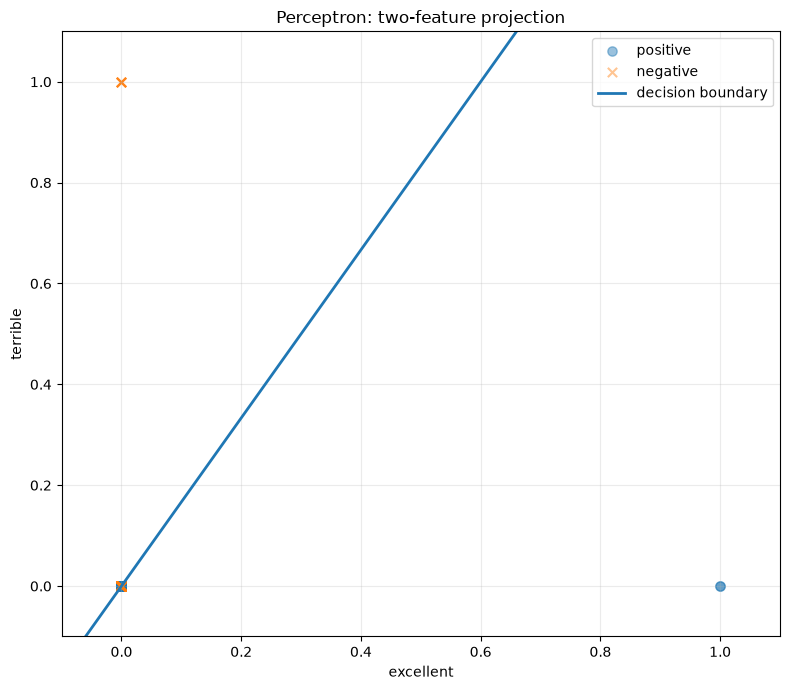

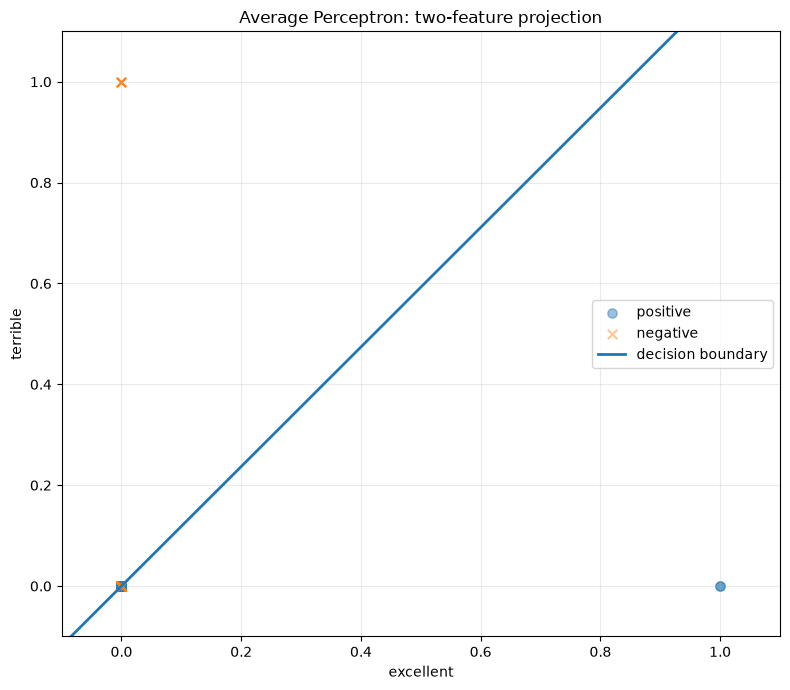

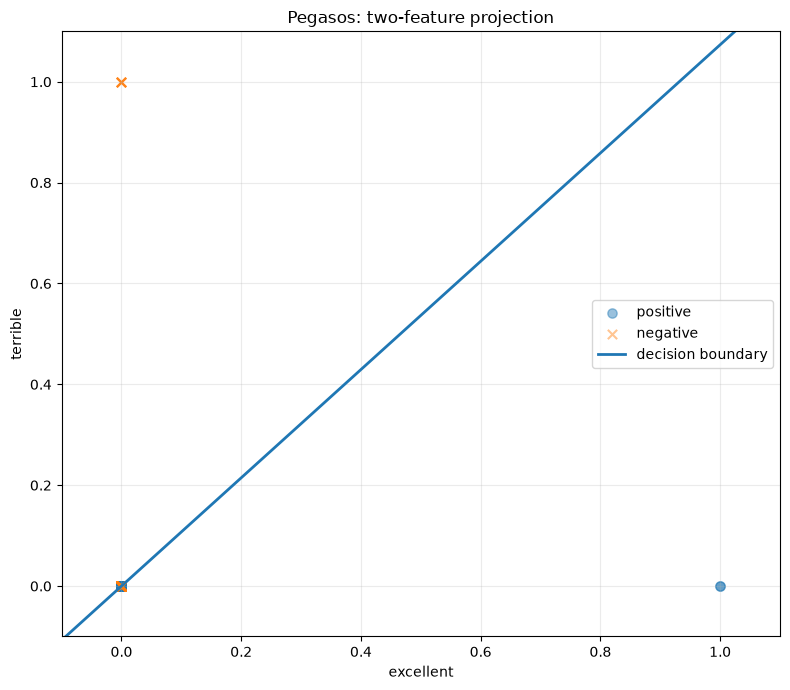

In [8]:
feature_words=[w for w in ('excellent','terrible') if w in vocabulary]
if len(feature_words)<2: feature_words=list(vocabulary)[:2]
feature_indices=[vocabulary[w] for w in feature_words]
points=np.array([[features.get(i,0.0) for i in feature_indices] for features in X_test])
x_values=np.linspace(-.1,1.1,200)
for name,weights in final_models.items():
    fig,ax=plt.subplots(figsize=(8,7))
    for label,marker in ((1,'o'),(-1,'x')):
        mask=y_test==label
        ax.scatter(points[mask,0],points[mask,1],marker=marker,s=45,alpha=.45,label='positive' if label==1 else 'negative')
    t1=weights.get(feature_indices[0],0.0); t2=weights.get(feature_indices[1],0.0)
    if abs(t2)>1e-12: ax.plot(x_values,-(t1/t2)*x_values,linewidth=2,label='decision boundary')
    elif abs(t1)>1e-12: ax.axvline(0,linewidth=2,label='decision boundary')
    ax.set_xlabel(feature_words[0]); ax.set_ylabel(feature_words[1]); ax.set_title(f'{name}: two-feature projection')
    ax.set_xlim(-.1,1.1); ax.set_ylim(-.1,1.1); ax.grid(True,alpha=.25); ax.legend(); plt.tight_layout(); plt.show()


## Conclusion

The final conclusions should be based on the measured validation accuracy, test accuracy, and training time. In particular, the experiment does not assume that Pegasos is universally faster or more accurate; it measures the behavior of these implementations on the same dataset and training budget.
